# Simple Audio Recognition — 8 Keywords (down, left, no, off, on, right, up, yes)

Replicates the official TensorFlow `simple_audio` tutorial pipeline (`audio_dataset_from_directory`, STFT spectrograms, the tutorial's CNN), but pointed at the **full** Speech Commands v0.02 dataset filtered down to these 8 words instead of the built-in `mini_speech_commands` set (which uses `go`/`stop` instead of `on`/`off`).

In [1]:
import os
import pathlib
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Download the full Speech Commands dataset (fresh)

This downloads and extracts the full v0.02 dataset (~2.3GB, 105k files, 35 words) — a fresh copy, separate from any previous project folder.

In [2]:
DATA_ROOT = pathlib.Path("data")
DATASET_PATH = DATA_ROOT / "speech_commands"
DATA_ROOT.mkdir(exist_ok=True)

if not DATASET_PATH.exists():
    DATASET_PATH.mkdir(parents=True)
    print("Downloading speech_commands_v0.02.tar.gz ...")
    archive_path = tf.keras.utils.get_file(
        "speech_commands_v0.02.tar.gz",
        origin="https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz",
        cache_dir=str(DATA_ROOT),
        cache_subdir="downloads"
    )
    print("Extracting ...")
    with tarfile.open(archive_path) as tar:
        tar.extractall(path=DATASET_PATH)
    print("Done.")
else:
    print("Dataset already present at:", DATASET_PATH)


2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 2177s 1us/step
Extracting ...
Done.


## Filter down to the 8 target commands

`tf.keras.utils.audio_dataset_from_directory` treats *every* subdirectory it's pointed at as a class, so we build a folder containing only the 8 word directories we want (as symlinks, to avoid duplicating the audio files on disk) and point the tutorial's API at that instead.

In [3]:
TARGET_COMMANDS = ["down", "left", "no", "off", "on", "right", "up", "yes"]

FILTERED_PATH = DATA_ROOT / "speech_commands_8"
FILTERED_PATH.mkdir(exist_ok=True)

for cmd in TARGET_COMMANDS:
    src = (DATASET_PATH / cmd).resolve()
    dst = FILTERED_PATH / cmd
    if not dst.exists():
        os.symlink(src, dst)

commands = np.array(sorted(TARGET_COMMANDS))
print("Commands:", commands)


Commands: ['down' 'left' 'no' 'off' 'on' 'right' 'up' 'yes']


## Load the dataset with `audio_dataset_from_directory`

Same call as the tutorial — this gives an 80/20 random validation split (not a speaker-disjoint split like the official `validation_list.txt`). `class_names` is derived alphabetically from the folder names, which matches your label mapping: `0→down, 1→left, 2→no, 3→off, 4→on, 5→right, 6→up, 7→yes`.

In [4]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=FILTERED_PATH,
    batch_size=64,
    validation_split=0.2,
    seed=0,
    output_sequence_length=16000,
    subset="both")

label_names = np.array(train_ds.class_names)
print()
print("label names:", label_names)


Found 30794 files belonging to 8 classes.
Using 24636 files for training.
Using 6158 files for validation.

label names: ['down' 'left' 'no' 'off' 'on' 'right' 'up' 'yes']


In [5]:
train_ds.element_spec


(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

The audio channel dimension isn't needed since this is single-channel audio — squeeze it out.

In [6]:
def squeeze(audio, labels):
    audio = tf.squeeze(audio, axis=-1)
    return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)


`audio_dataset_from_directory` only gives train/val, so split val in half to carve out a held-out test set (same trick as the tutorial).

In [7]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

for example_audio, example_labels in train_ds.take(1):
    print(example_audio.shape)
    print(example_labels.shape)


(64, 16000)
(64,)


## Plot a few waveforms

In [8]:
label_names[example_labels[:9].numpy()]


array(['down', 'left', 'right', 'up', 'right', 'yes', 'no', 'no', 'yes'],
      dtype='<U5')

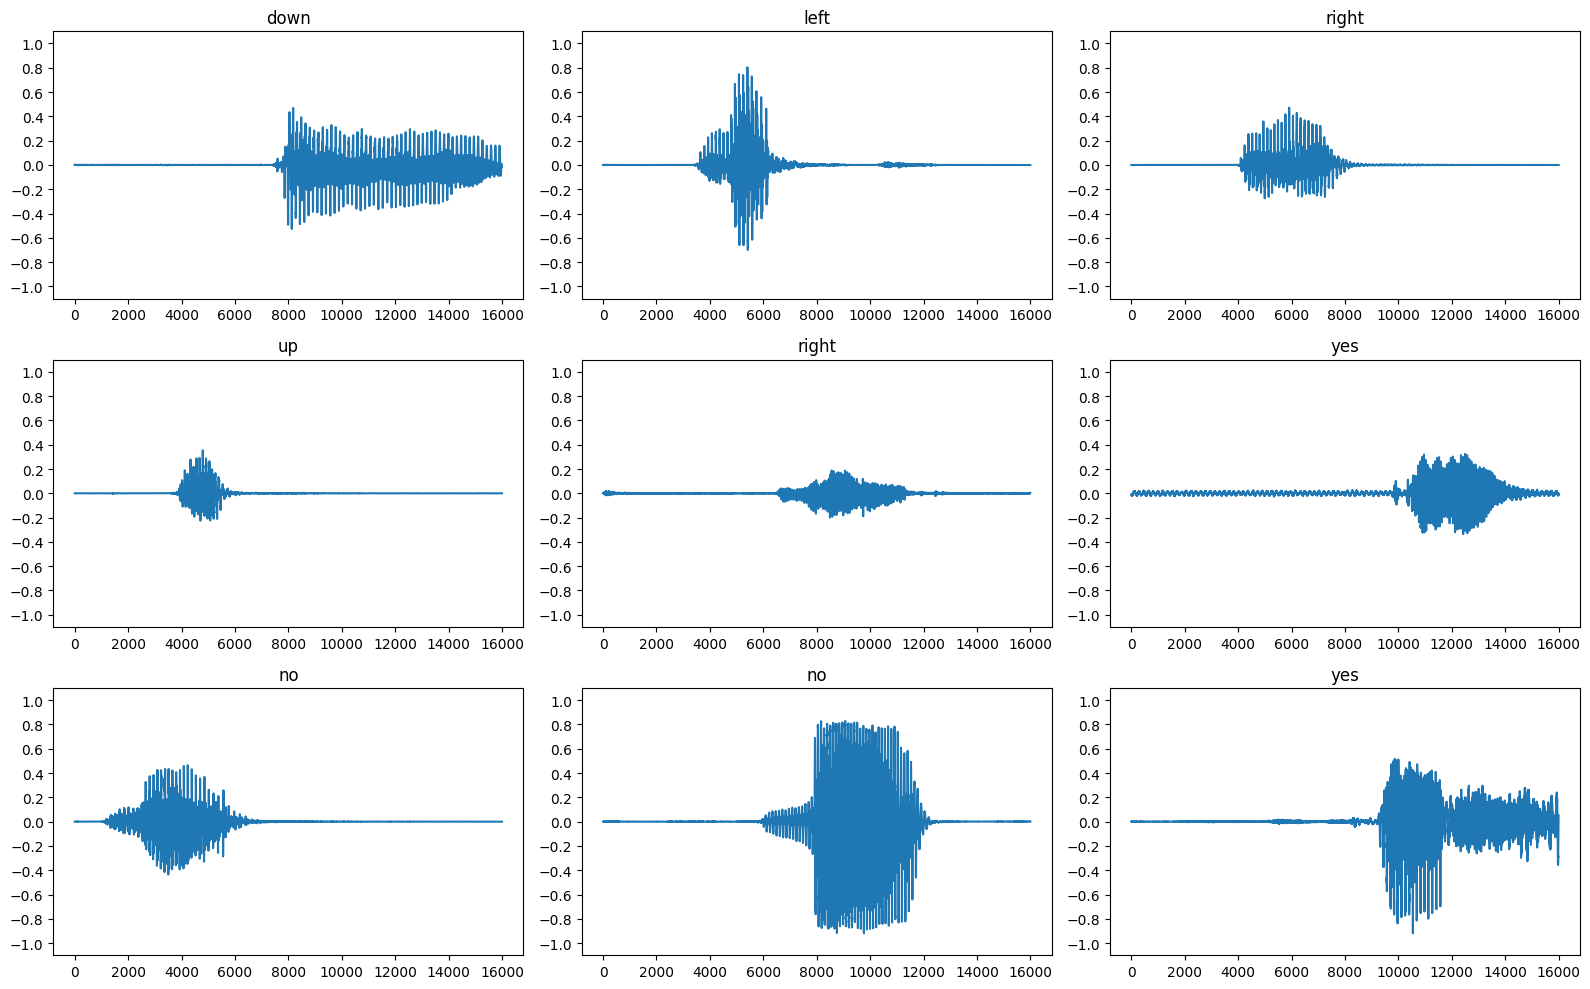

In [9]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
    plt.subplot(rows, cols, i + 1)
    audio_signal = example_audio[i]
    plt.plot(audio_signal)
    plt.title(label_names[example_labels[i]])
    plt.yticks(np.arange(-1.2, 1.2, 0.2))
    plt.ylim([-1.1, 1.1])
plt.tight_layout()
plt.show()


## Convert waveforms to spectrograms

In [10]:
def get_spectrogram(waveform):
    # Convert the waveform to a spectrogram via a STFT.
    spectrogram = tf.signal.stft(
        waveform, frame_length=255, frame_step=128)
    # Obtain the magnitude of the STFT.
    spectrogram = tf.abs(spectrogram)
    # Add a `channels` dimension, so that the spectrogram can be used
    # as image-like input data with convolution layers (which expect
    # shape (`batch_size`, `height`, `width`, `channels`).
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram


In [11]:
for i in range(3):
    label = label_names[example_labels[i]]
    waveform = example_audio[i]
    spectrogram = get_spectrogram(waveform)

    print("Label:", label)
    print("Waveform shape:", waveform.shape)
    print("Spectrogram shape:", spectrogram.shape)
    print("Audio playback")
    display.display(display.Audio(waveform, rate=16000))


Label: down
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: left
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: right
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [12]:
def plot_spectrogram(spectrogram, ax):
    if len(spectrogram.shape) > 2:
        assert len(spectrogram.shape) == 3
        spectrogram = np.squeeze(spectrogram, axis=-1)
    # Convert the frequencies to log scale and transpose, so that the time is
    # represented on the x-axis (columns² and frequencies on the y-axis (rows).
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)


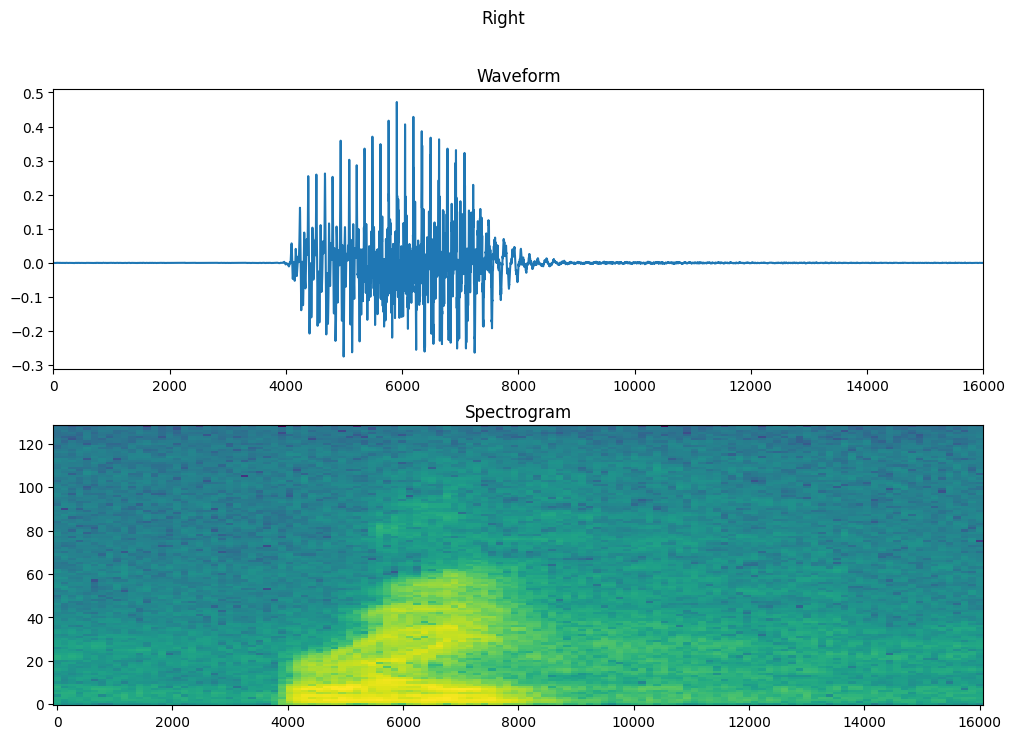

In [13]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title("Waveform")
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title("Spectrogram")
plt.suptitle(label.title())
plt.show()


Build spectrogram datasets from the audio datasets:

In [14]:
def make_spec_ds(ds):
    return ds.map(
        map_func=lambda audio, label: (get_spectrogram(audio), label),
        num_parallel_calls=tf.data.AUTOTUNE)

train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)
test_spectrogram_ds = make_spec_ds(test_ds)


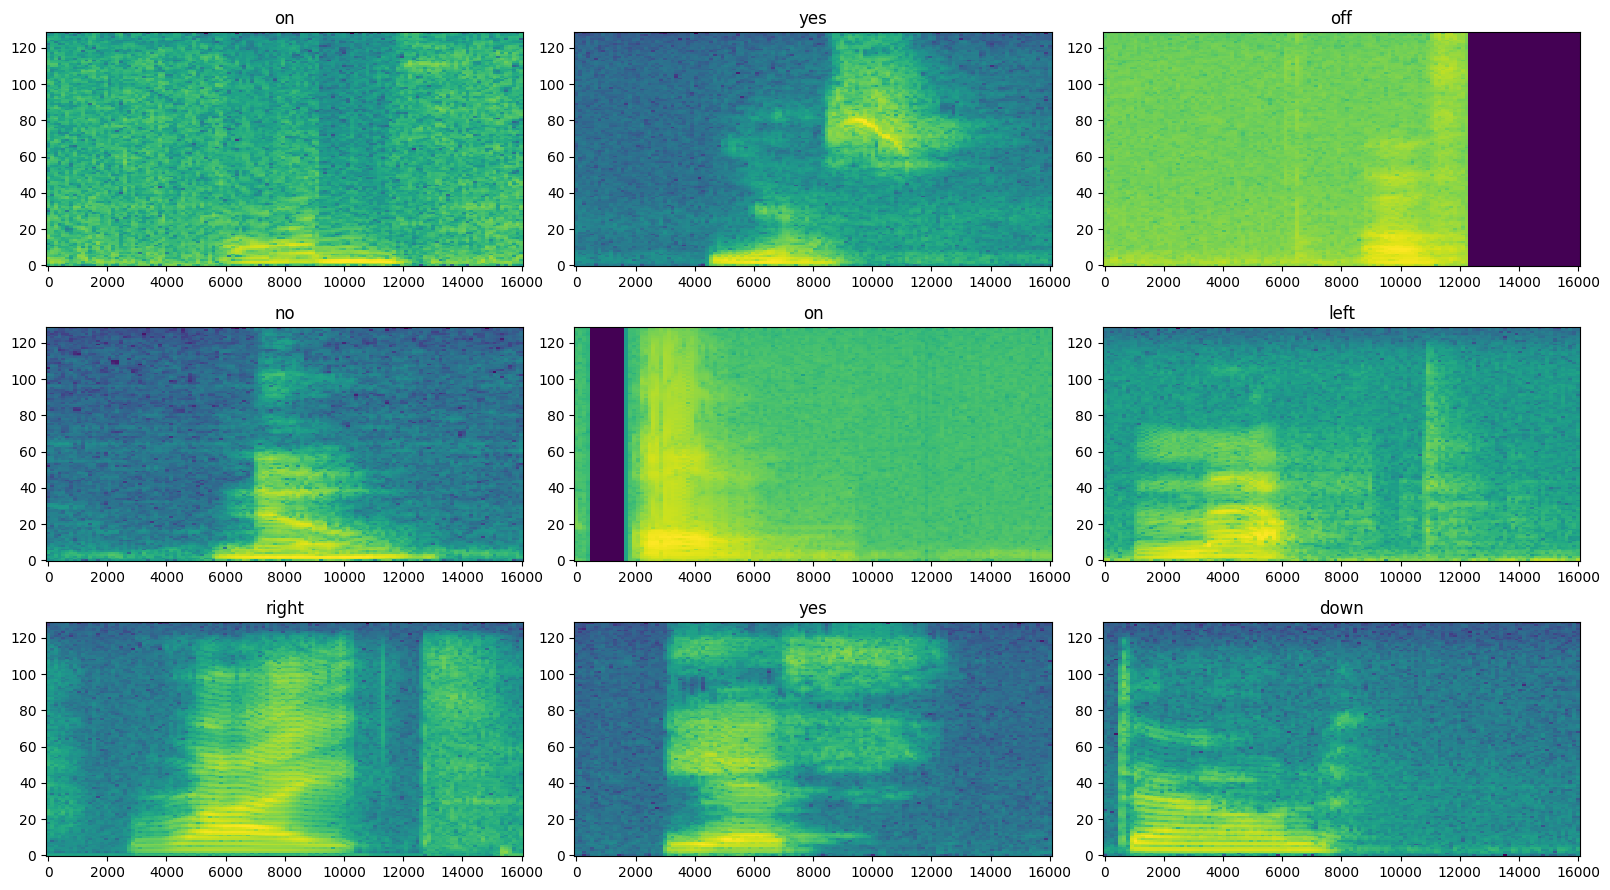

In [15]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
    break

rows = 3
cols = 3
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.tight_layout()
plt.show()


## Build and train the model

Cache and prefetch to avoid recomputing spectrograms every epoch.

In [16]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)
test_spectrogram_ds = test_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)


In [17]:
input_shape = example_spectrograms.shape[1:]
print("Input shape:", input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),

    # Downsample spectrogram
    layers.Resizing(32, 32),

    # Normalize
    norm_layer,

    # Initial convolution
    layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    # Depthwise separable convolution block 1
    layers.DepthwiseConv2D(
        kernel_size=3,
        padding="same"
    ),
    layers.BatchNormalization(momentum=0.9),
    layers.ReLU(),

    layers.Conv2D(
        128,
        kernel_size=1,
        padding="same"
    ),
    layers.BatchNormalization(momentum=0.9),
    layers.ReLU(),

    # Depthwise separable convolution block 2
    layers.DepthwiseConv2D(
        kernel_size=3,
        padding="same"
    ),
    layers.BatchNormalization(momentum=0.9),
    layers.ReLU(),

    layers.Conv2D(
        256,
        kernel_size=1,
        padding="same"
    ),
    layers.BatchNormalization(momentum=0.9),
    layers.ReLU(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.25),

    layers.Dense(num_labels)
])

model.summary()


Input shape: (124, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 32, 32, 64)     │           640 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 32, 32, 128)    │         1,280 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 256)    │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,267 (188.55 KB)

 Trainable params: 47,112 (184.03 KB)

 Non-trainable params: 1,155 (4.52 KB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)


In [19]:
EPOCHS = 30

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 178s 457ms/step - accuracy: 0.5663 - loss: 1.3432 - val_accuracy: 0.2360 - val_loss: 6.6120 - learning_rate: 0.0010
Epoch 2/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 197s 511ms/step - accuracy: 0.7958 - loss: 0.7010 - val_accuracy: 0.6755 - val_loss: 0.9351 - learning_rate: 0.0010
Epoch 3/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 198s 515ms/step - accuracy: 0.8389 - loss: 0.5255 - val_accuracy: 0.1768 - val_loss: 6.9655 - learning_rate: 0.0010
Epoch 4/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8575 - loss: 0.4538
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
385/385 ━━━━━━━━━━━━━━━━━━━━ 197s 512ms/step - accuracy: 0.8592 - loss: 0.4476 - val_accuracy: 0.4329 - val_loss: 2.7380 - learning_rate: 0.0010
Epoch 5/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 200s 518ms/step - accuracy: 0.8784 - loss: 0.3839 - val_accuracy: 0.6507 - val_loss: 1.1332 - learning_rate: 5.0000e-04
Epoch 6/30
385/385 ━━━━━━━━━━━━━━━━━━━━ 197s 513ms/step - accur

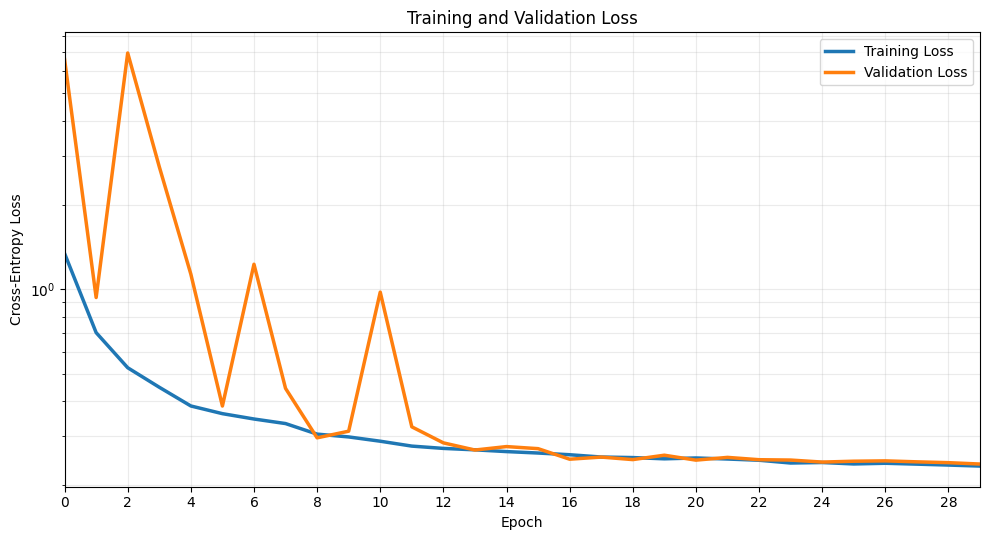

In [38]:
import matplotlib.pyplot as plt

epochs = range(len(history.history["loss"]))

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(10, 5.5))

plt.plot(epochs, train_loss,
         label="Training Loss",
         linewidth=2.5)

plt.plot(epochs, val_loss,
         label="Validation Loss",
         linewidth=2.5)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")

plt.yscale("log")

plt.xlim(0, len(epochs) - 1)
plt.xticks(range(0, len(epochs), 2))

plt.grid(alpha=0.25, which="both")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate the model performance

In [21]:
model.evaluate(test_spectrogram_ds, return_dict=True)


49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.9297 - loss: 0.2326


{'accuracy': 0.9296824336051941, 'loss': 0.23259447515010834}

### Display a confusion matrix

49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step


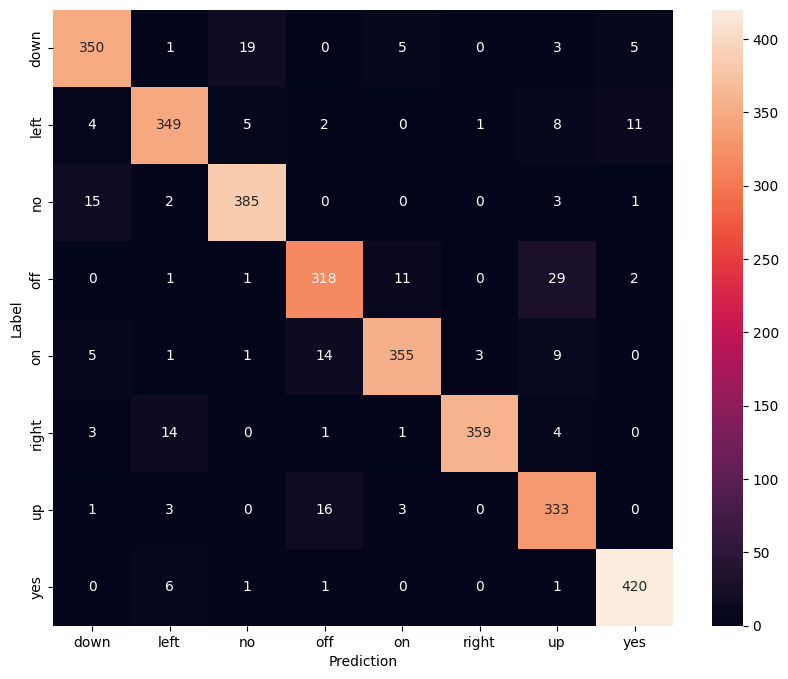

In [22]:
y_pred = model.predict(test_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(test_spectrogram_ds.map(lambda s, lab: lab)), axis=0)
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, xticklabels=label_names, yticklabels=label_names,
            annot=True, fmt="g")
plt.xlabel("Prediction")
plt.ylabel("Label")
plt.show()


## Run inference on an audio file

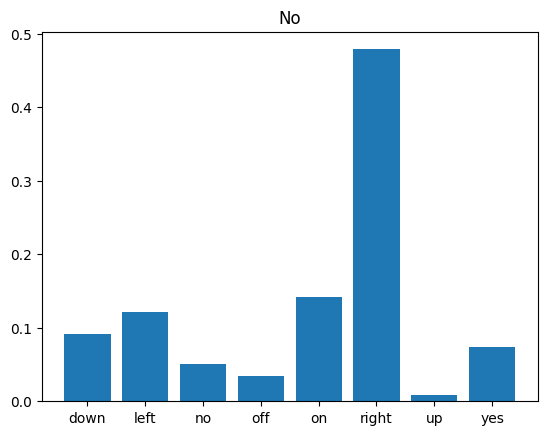

In [23]:
x = FILTERED_PATH / "no" / os.listdir(FILTERED_PATH / "no")[0]
x = tf.io.read_file(str(x))
x, sample_rate = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000)
x = tf.squeeze(x, axis=-1)
waveform = x
x = get_spectrogram(x)
x = x[tf.newaxis, ...]

prediction = model(x)
x_labels = list(label_names)
plt.bar(x_labels, tf.nn.softmax(prediction[0]))
plt.title("No")
plt.show()

display.display(display.Audio(waveform, rate=16000))


## Export the model with preprocessing

Wraps the raw model so it can accept either a filename or a raw waveform directly, without the caller needing to reimplement the spectrogram pipeline.

In [24]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string))
    self.__call__.get_concrete_function(
       x=tf.TensorSpec(shape=[None, 16000], dtype=tf.float32))

  @tf.function
  def __call__(self, x):
    if x.dtype == tf.string:
      x = tf.io.read_file(x)
      x, _ = tf.audio.decode_wav(x, desired_channels=1, desired_samples=16000,)
      x = tf.squeeze(x, axis=-1)
      x = x[tf.newaxis, :]

    x = get_spectrogram(x)
    result = self.model(x, training=False)

    class_ids = tf.argmax(result, axis=-1)
    class_names = tf.gather(label_names, class_ids)
    return {"predictions": result,
            "class_ids": class_ids,
            "class_names": class_names}


In [25]:
export = ExportModel(model)
export(tf.constant(str(FILTERED_PATH / "no" / os.listdir(FILTERED_PATH / "no")[0])))


{'predictions': <tf.Tensor: shape=(1, 8), dtype=float32, numpy=
 array([[ 1.4544137, -1.3896304,  2.5494587, -3.8573146, -4.010739 ,
         -2.2113066, -0.6406044, -0.4323515]], dtype=float32)>,
 'class_ids': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([2])>,
 'class_names': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'no'], dtype=object)>}

In [26]:
tf.saved_model.save(export, "saved")
imported = tf.saved_model.load("saved")
imported(waveform[tf.newaxis, :])


INFO:tensorflow:Assets written to: saved\assets


INFO:tensorflow:Assets written to: saved\assets


{'class_ids': <tf.Tensor: shape=(1,), dtype=int64, numpy=array([2])>,
 'class_names': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'no'], dtype=object)>,
 'predictions': <tf.Tensor: shape=(1, 8), dtype=float32, numpy=
 array([[ 1.4544137, -1.3896304,  2.5494587, -3.8573146, -4.010739 ,
         -2.2113066, -0.6406044, -0.4323515]], dtype=float32)>}